# What datasets are compatibile with TiTiler-CMR? 

## TiTiler-CMR Compatibility Report

This document reports datasets which have found to be compatible with TiTiler-CMR's tiling functionality.

## What is tested?

TiTiler-CMR has `tiles` and `statistics` endpoints (`timeseries/statistics` being an expansion of the `statistics` group). The `tiles` and `statistics` endpoints read data from source files. Some files work with TiTiler-CMR and some do not, for reasons which are detailed in this report. While it is highly likely the datasets compatible with tiling are also compatible for statistics, testing is only reported on **tiling** for now.

This report provides:

1. A listing of the datasets found to be compatible with TiTiler-CMR's **tiling** endpoints.
2. An overview of what **types of datasets** were found compatible and incompatible.

See [titiler-cmr-compatibility's METHODOLOGY](https://github.com/developmentseed/titiler-cmr-compatibility/blob/main/METHODOLOGY.md) documentation for a detailed explanation of how datasets were tested.

⚠️ This notebook requires access to the `s3://veda-odd-scratch` and an installation of `pandas` and `fastparquet` or `pyarrow`.

## Step 0: Download results of testing

First, we must download the results of our testing from [titiler-cmr-compatibility](https://github.com/developmentseed/titiler-cmr-compatibility).



In [159]:
!aws s3 cp s3://veda-odd-scratch/titiler-cmr-compatibility/tiling_results-11-24-2025.parquet tiling_results-11-24-2025.parquet

download: s3://veda-odd-scratch/titiler-cmr-compatibility/tiling_results-11-24-2025.parquet to ./tiling_results-11-24-2025.parquet


## What datasets are compatible?

From the results file, we load the datasets found to be compatible, using the `tiling_compatible` column.

In [ ]:
import pandas as pd
import plotting
from IPython.display import display, Markdown

df = pd.read_parquet("tiling_results-11-24-2025.parquet")
num_all_datasets = len(df)
compatible_datasets = df[df.tiling_compatible]
num_compatible_datasets = len(compatible_datasets)

display(
    Markdown(
        f"### Out of {num_all_datasets} datasets tested, **{num_compatible_datasets} were found to be compatible**."
    )
)

### Out of 10047 datasets tested, **719 were found to be compatible**.

Let's look at a few of these datasets, so we know what information is available.

In [161]:
compatible_datasets.head()

,collection_concept_id,collection_short_name_and_version,concept_id,data_center,data_url,backend,format,extension,tiling_compatible,incompatible_reason,error_message,tiles_url,variable,data_variables,num_granules,processing_level,groups
339,C1231627223-GES_DISC,TRMM_3B42RT.7,G1289966438-GES_DISC,GES_DISC,s3://gesdisc-cumulus-prod-protected/TRMM_RT/TR...,xarray,netCDF,nc4,True,None,None,https://staging.openveda.cloud/api/titiler-cmr...,precipitation,"[precipitation, precipitation_error, source, u...",57961.0,3,None
341,C1233767569-GES_DISC,GLDAS_NOAH025_M.2.0,G1413722274-GES_DISC,GES_DISC,s3://gesdisc-cumulus-prod-protected/GLDAS/GLDA...,xarray,netCDF,nc4,True,None,None,https://staging.openveda.cloud/api/titiler-cmr...,Swnet_tavg,"[time_bnds, Swnet_tavg, Lwnet_tavg, Qle_tavg, ...",804.0,4,None
343,C1233767545-GES_DISC,GLDAS_NOAH025_3H.2.0,G1415076891-GES_DISC,GES_DISC,s3://gesdisc-cumulus-prod-protected/GLDAS/GLDA...,xarray,netCDF,nc4,True,None,None,https://staging.openveda.cloud/api/titiler-cmr...,Swnet_tavg,"[time_bnds, Swnet_tavg, Lwnet_tavg, Qle_tavg, ...",195775.0,4,None
345,C1233767548-GES_DISC,GLDAS_NOAH10_3H.2.0,G1414725957-GES_DISC,GES_DISC,s3://gesdisc-cumulus-prod-protected/GLDAS/GLDA...,xarray,netCDF,nc4,True,None,None,https://staging.openveda.cloud/api/titiler-cmr...,Swnet_tavg,"[time_bnds, Swnet_tavg, Lwnet_tavg, Qle_tavg, ...",195775.0,4,None
513,C1239536905-GES_DISC,TRMM_3B42_Daily.7,G1289922264-GES_DISC,GES_DISC,s3://gesdisc-cumulus-prod-protected/TRMM_L3/TR...,xarray,netCDF,nc4,True,None,None,https://staging.openveda.cloud/api/titiler-cmr...,precipitation,"[precipitation, precipitation_cnt, IRprecipita...",8034.0,3,None


The number of compatible datasets are a fraction of the total number of datasets, but it is too many to display here. So we write these to a CSV for inspection.


In [162]:
compatible_datasets.to_csv("compatible_datasets.csv", index=False)

## What types of datasets are compatible?

* GES_DISC, PODAAC, ORNLDAAC and OBDAAC have the most compatible datasets.
* Most compatible datasets are processing level 3 or 4.
* Most compatible datasets are NetCDF-4 format, however ~200 are Cloud-Optimized GeoTIFFs (COGs).

Now for some pie 🥧 charts.

### Compatible datasets by data center

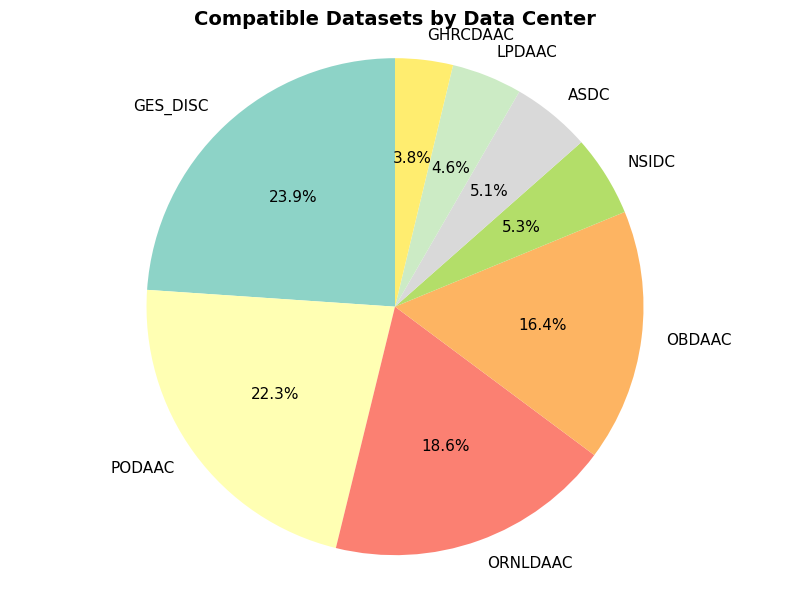

In [163]:
data_center_counts = compatible_datasets.data_center.value_counts(dropna=False)
data_center_names = data_center_counts.index

plotting.create_pie_chart(
    data_center_names, data_center_counts, "Compatible Datasets by Data Center"
)

### Compatible datasets by processing level

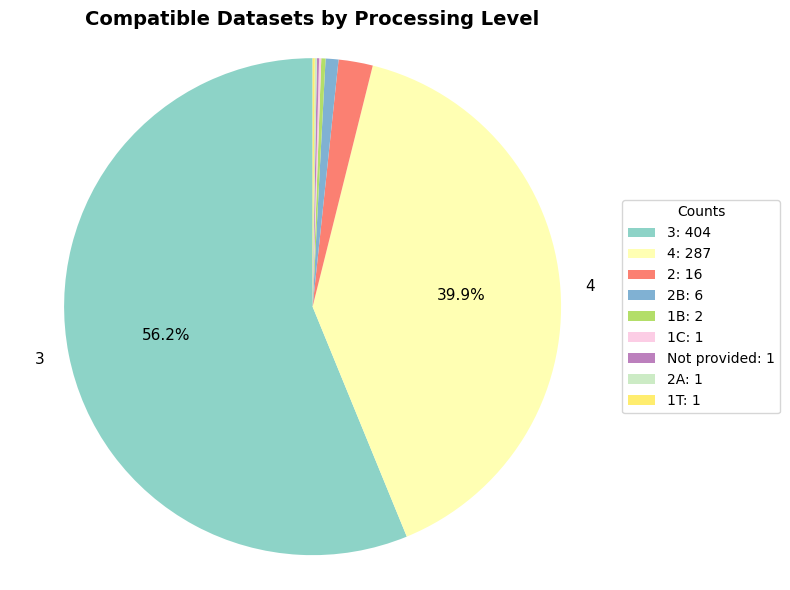

In [164]:
processing_level_counts = compatible_datasets.processing_level.value_counts(
    dropna=False
)
processing_level_ids = processing_level_counts.index

plotting.create_pie_chart(
    processing_level_ids,
    processing_level_counts,
    "Compatible Datasets by Processing Level",
    True,
    top_n=2,
)

### Compatible datasets by file format

Not all datasets have the `format` attribute, so use the `extension` attribute.


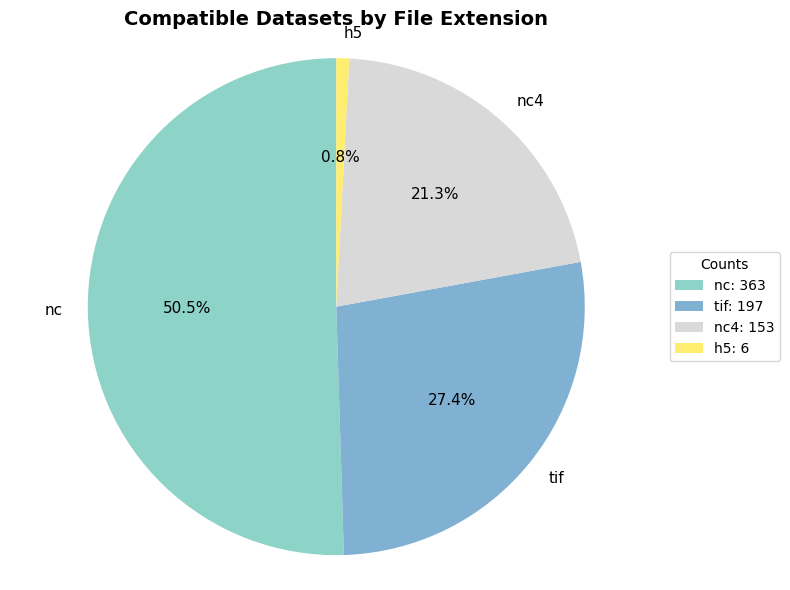

In [167]:
extension_counts = compatible_datasets.extension.value_counts(dropna=False)
extension_names = extension_counts.index

plotting.create_pie_chart(
    extension_names, extension_counts, "Compatible Datasets by File Extension", True
)

## What datasets are incompatible and why?

Only about 7% of datasets were found to be compatible. What's up with the other 93%?

The number 1 reason that datasets are deemed incompatible is because of an **unsupported format**.

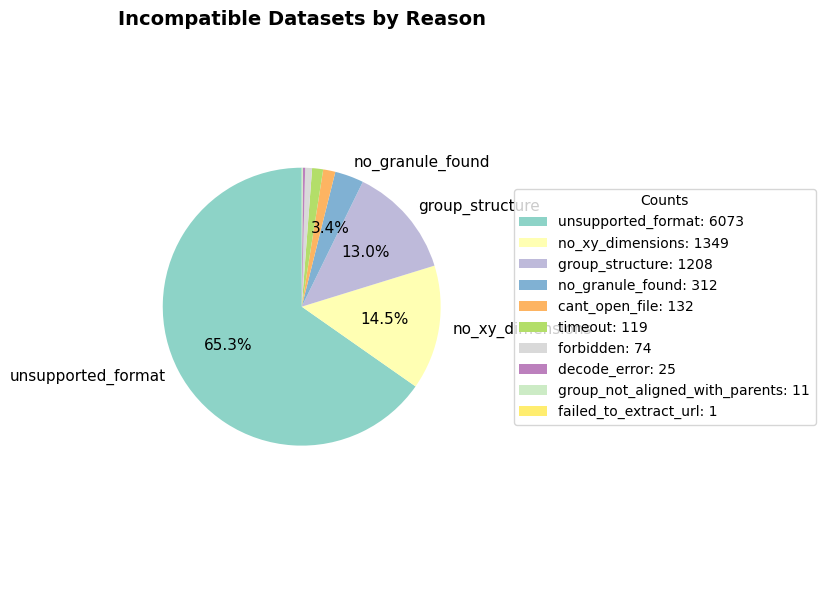

In [170]:
incompatible_reason_counts = df["incompatible_reason"].value_counts()
incompatible_reason_names = incompatible_reason_counts.index
incompatible_reason_counts.columns = ["Incompatible Reason", "Count"]
plotting.create_pie_chart(
    incompatible_reason_names,
    incompatible_reason_counts,
    "Incompatible Datasets by Reason",
    True,
    4,
)

### Unsupported formats

A majority of datasets are an unsupported format. Supported formats and extensions were whitelisted, see [`titiler-cmr-compatibility's constants.py`](https://github.com/developmentseed/titiler-cmr-compatibility/blob/main/titiler_cmr_compatibility/constants.py).

To determine if a collection had files of a supported or unsupported format, `titiler-cmr-compatibility` inspects the collection and granule metadata for a file format property. If no format property is defined, the testing code extracts the file extension.

Datasets were classified as having an unsupported format when, in this order:

1. The format was explicitly defined in the metadata and that format was not in the list of supported formats.
2. If no format was specified in the metadata, the file extension was extracted and compared against the list of supported extensions.
3. Since not all file extensions fully describe the file format (for example, `.tif` could be a cloud-optimized or not-cloud-optimized GeoTIFF, and `.nc` could be NetCDF-4 or an earlier NetCDF version), we proceed to opening files which have an ambiguous file format. We attempt to open all files with a file extension in the list of supported extensions. Sometimes this resulted in errors including the sub-strings `is not the signature of a valid netCDF4 file` or `Cannot seek streaming HTTP file`, indicating unsupported formats.

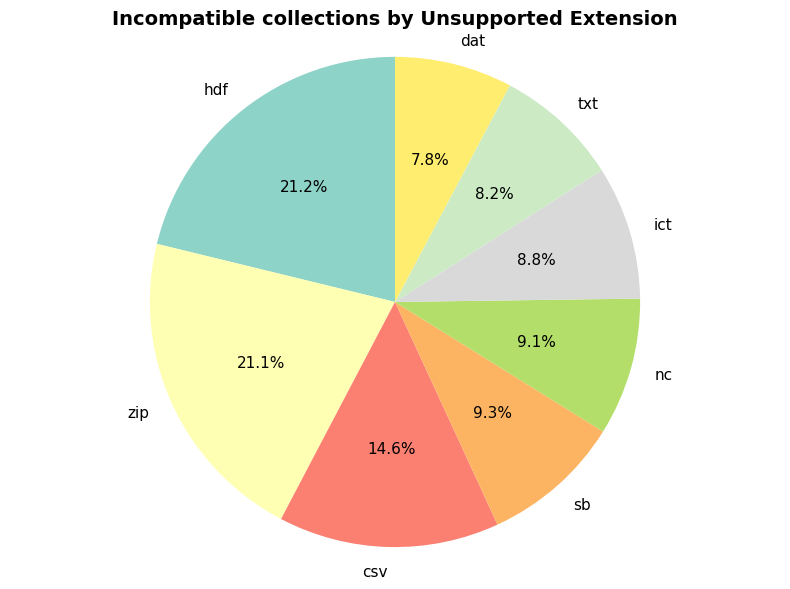

In [171]:
unsupported_format_subset_df = df[df["incompatible_reason"] == "unsupported_format"]
unsupported_extension_counts = unsupported_format_subset_df.extension.value_counts(
    dropna=False
)[0:8]
unsupported_extension_count_names = unsupported_extension_counts.index
plotting.create_pie_chart(
    unsupported_extension_count_names,
    unsupported_extension_counts,
    "Incompatible collections by Unsupported Extension",
)

### No X,Y dimensions found

The second most common reason datasets were deemed incompatible was [titiler.xarray.io](https://github.com/developmentseed/titiler/blob/v0.25.0/src/titiler/xarray/titiler/xarray/io.py#L127) could not determine the x and y dimensions from the dimensions of the dataset. This represents a characteristic, rather than technical, compatibility issue, as x, y dimensions are necessary to visualize data on a map.

However, many of these datasets are characterised as processing level 3 or 4. Further investigation could be warranted.

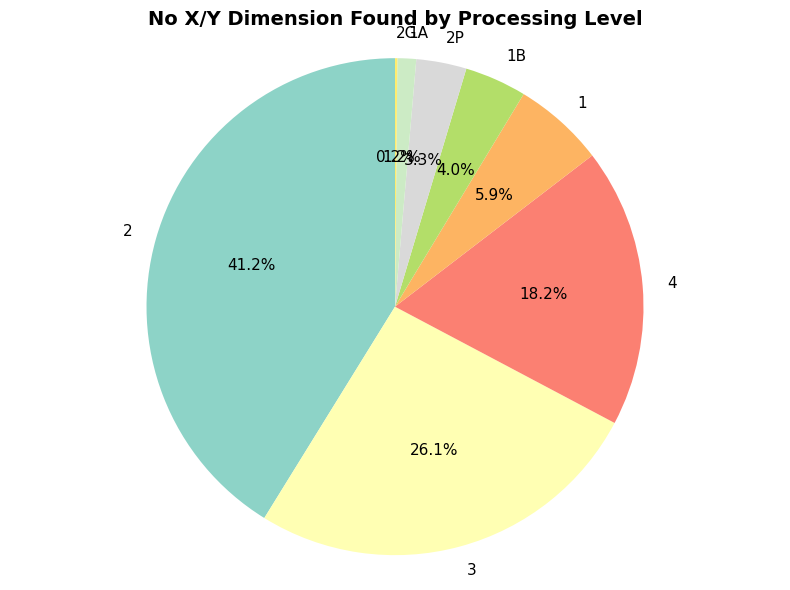

In [157]:
no_xy_dimensions_subset_df = df[df["incompatible_reason"] == "no_xy_dimensions"]
no_xy_counts = no_xy_dimensions_subset_df.processing_level.value_counts(dropna=False)[
    0:8
]
no_xy_count_names = no_xy_counts.index
plotting.create_pie_chart(
    no_xy_count_names, no_xy_counts, "No X/Y Dimension Found by Processing Level"
)

### Group Structure

Many HDF5 and some NetCDF-4 datasets use a group (aka hierarchical structure). At time of writing, files with groups are not supported by TiTiler-CMR, but we see that it easily could be in the near future. 

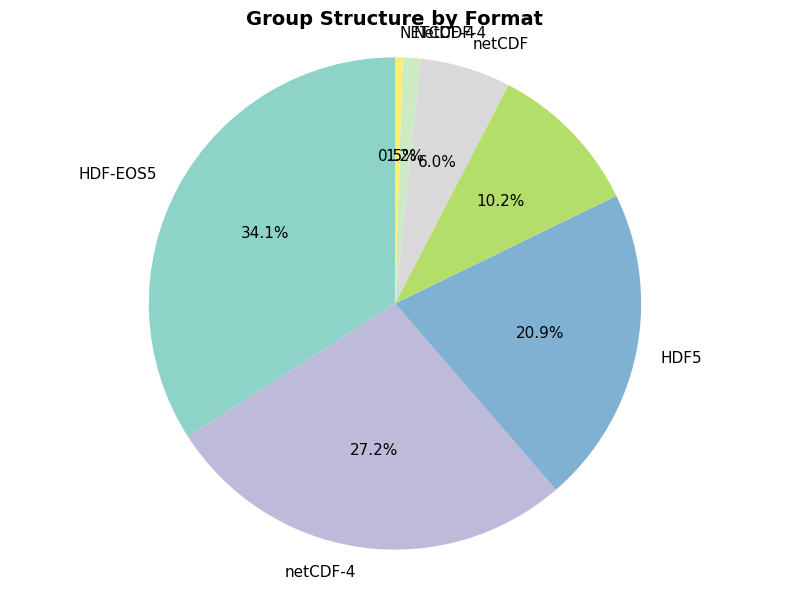

In [158]:
group_structure_subset_df = df[df["incompatible_reason"] == "group_structure"]
format_counts = group_structure_subset_df.format.value_counts(dropna=False)
format_counts_names = format_counts.index
plotting.create_pie_chart(
    format_counts_names, format_counts, "Group Structure by Format"
)

### Other incompatibility issues

The rest of the datasets were deemed to be incompatible for the following reasons:

* No granules returned.
* Assorted errors when trying to open the file with xarray or rasterio, which was driven by an assortment of (mostly data-type appearing) errors.
* `Forbidden` or `Unauthorized` errors.
* Timing out (each dataset was given 30 seconds to process).
* Out of memory (OOM) errors: these datasets are not representd in the results as OOM errors cause the lambda function to crash.

Timing out and OOM errors both signal that these datasets are potentially too large to enable dynamic tiling in an acceptable responsive time frame.

# Summary and Next Steps

While this process provies nice listing and number of datasets that are compatible with TiTiler-CMR, individual datasets will still require testing and assessment. However we feel confident that those datasets that were deemed compatible could be advertised as so through metadata.

Next steps:
* Support grouped datasets in TiTiler-CMR and re-run assessment.
* Discuss how to "publish" or otherwise advertise datasets that can be used with TiTiler-CMR.

